<a href="https://colab.research.google.com/github/Shubham12864/Boston-House-Price-Prediction/blob/main/Boston_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv('Boston.csv')

In [ ]:
df.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   crim        506 non-null    float64
 2   zn          506 non-null    float64
 3   indus       506 non-null    float64
 4   chas        506 non-null    int64  
 5   nox         506 non-null    float64
 6   rm          506 non-null    float64
 7   age         506 non-null    float64
 8   dis         506 non-null    float64
 9   rad         506 non-null    int64  
 10  tax         506 non-null    int64  
 11  ptratio     506 non-null    float64
 12  black       506 non-null    float64
 13  lstat       506 non-null    float64
 14  medv        506 non-null    float64
dtypes: float64(11), int64(4)
memory usage: 59.4 KB


In [ ]:
df.describe()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,253.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,1.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,127.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,253.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,379.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,506.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


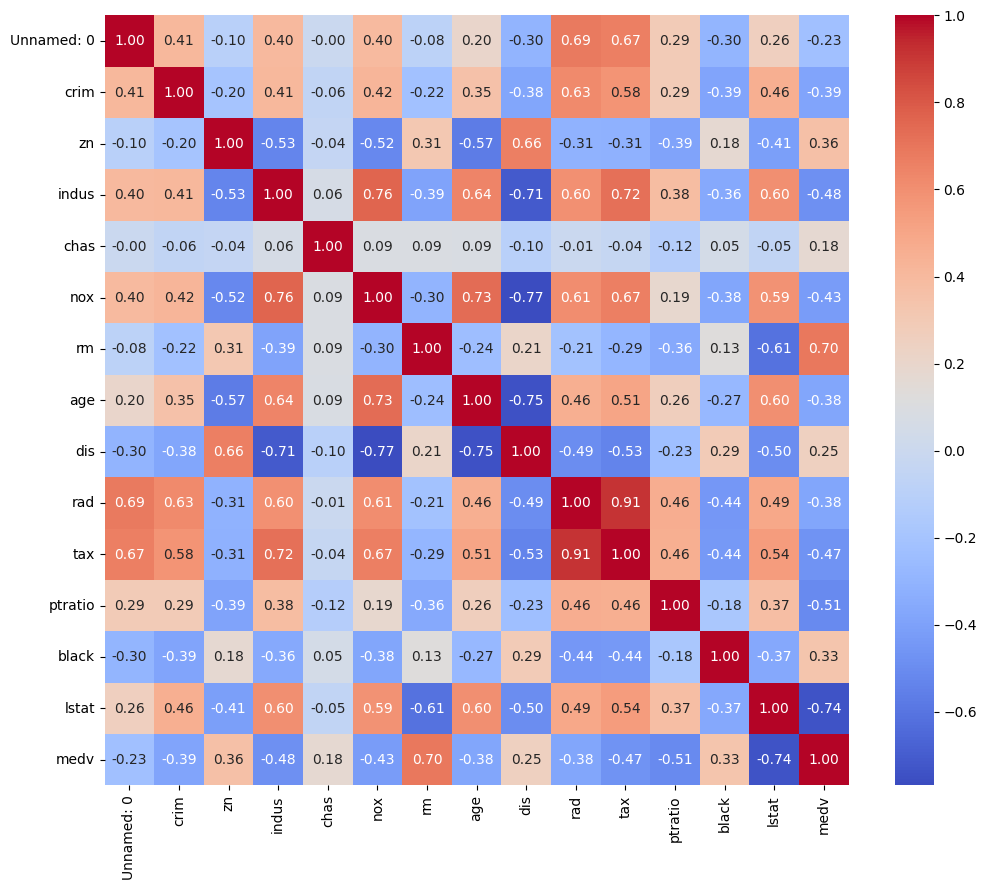

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
# The 'annot=True' adds the actual correlation numbers inside the boxes
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [ ]:
df.shape

(506, 15)

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0


In [ ]:
df.corr()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
Unnamed: 0,1.000000,0.407407,-0.103393,0.399439,-0.003759,0.398736,-0.079971,0.203784,-0.302211,0.686002,0.666626,0.291074,-0.295041,0.258465,-0.226604
crim,0.407407,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.103393,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.399439,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.003759,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.398736,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.079971,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.203784,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.302211,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.686002,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626


<Axes: xlabel='tax', ylabel='crim'>

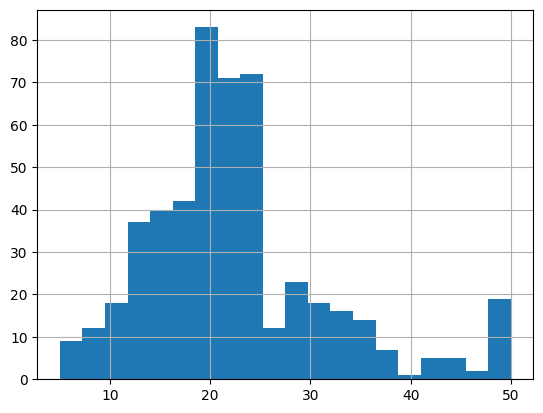

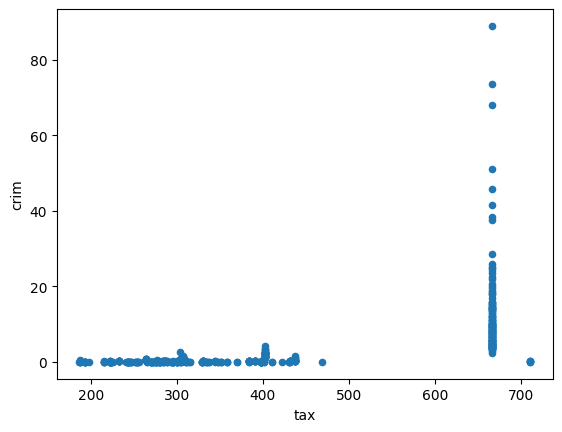

In [ ]:
df['medv'].hist(bins=20)
df.plot.scatter(x = 'tax', y = 'crim')

<Axes: >

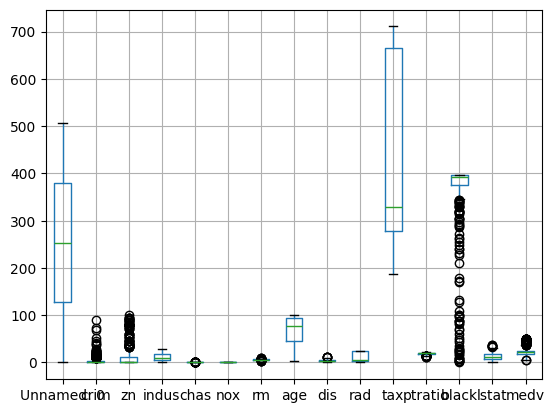

In [ ]:
df.boxplot()

In [19]:
X = df.drop(columns=['medv', 'Unnamed: 0'])
y = df['medv']

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [9]:
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()


In [10]:
def zscore(X):
  mu = np.mean(X, axis =0)
  sigma = np.std(X,axis=0)
  return (X - mu) / sigma

In [11]:
X_std = zscore(X_train_np)
X_test_std = zscore(X_test_np)


In [12]:
m,n = X_std.shape
lr = 0.0001
w_in = np.random.randn(n) * 0.01
b_in = 0.0
ite = 100000


In [13]:
def compute(X,w,b):
  fwb = np.dot(X,w) + b
  return fwb

In [14]:
def cost_fun(X,y,w,b):
   m = X.shape[0]
   fwb = np.dot(X,w) + b
   total_cost = (1/ (2 * m)) * np.sum((fwb - y) ** 2)
   return total_cost

In [15]:
def gradient_descent(X,y,w,b,lr,ite):
  m = X.shape[0]
  J_history =[]
  for i in range(ite):
    fwb = np.dot(X,w) + b
    error = fwb - y
    dj_dw = np.dot(X.T,error) / m
    dj_db = np.sum(error) / m
    w = w - (lr * dj_dw)
    b = b - (lr * dj_db)
    current_cost = cost_fun(X, y, w, b)
    J_history.append(current_cost)
    if i % 1000 == 0:
      print(f"Iteration {i:5d}: Cost = {current_cost:.4f}")

  return w,b,J_history

In [20]:
w_norm, b_norm, J_history = gradient_descent(X_std,y_train,w_in,b_in,lr,ite)
print("\n--- Final Trained Parameters ---")
print("Optimized weights (w):", w_norm)
print("Optimized bias (b):   ", b_norm)

Iteration     0: Cost = 303.2305
Iteration  1000: Cost = 242.0406
Iteration  2000: Cost = 197.2487
Iteration  3000: Cost = 162.4245
Iteration  4000: Cost = 134.5826
Iteration  5000: Cost = 112.0483
Iteration  6000: Cost = 93.7119
Iteration  7000: Cost = 78.7556
Iteration  8000: Cost = 66.5419
Iteration  9000: Cost = 56.5613
Iteration 10000: Cost = 48.4019
Iteration 11000: Cost = 41.7288
Iteration 12000: Cost = 36.2696
Iteration 13000: Cost = 31.8019
Iteration 14000: Cost = 28.1446
Iteration 15000: Cost = 25.1495
Iteration 16000: Cost = 22.6958
Iteration 17000: Cost = 20.6850
Iteration 18000: Cost = 19.0364
Iteration 19000: Cost = 17.6842
Iteration 20000: Cost = 16.5745
Iteration 21000: Cost = 15.6633
Iteration 22000: Cost = 14.9146
Iteration 23000: Cost = 14.2990
Iteration 24000: Cost = 13.7925
Iteration 25000: Cost = 13.3753
Iteration 26000: Cost = 13.0314
Iteration 27000: Cost = 12.7475
Iteration 28000: Cost = 12.5129
Iteration 29000: Cost = 12.3187
Iteration 30000: Cost = 12.1576
It

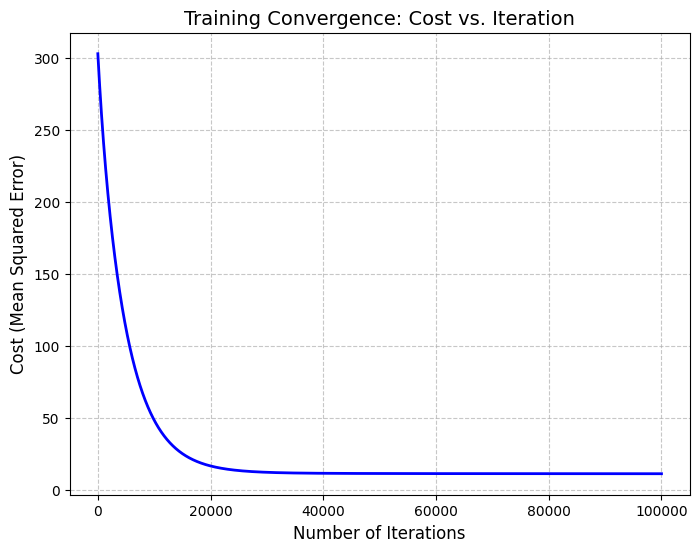

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(J_history, color='blue', linewidth=2)
plt.title("Training Convergence: Cost vs. Iteration", fontsize=14)
plt.xlabel("Number of Iterations", fontsize=12)
plt.ylabel("Cost (Mean Squared Error)", fontsize=12)

# Add a grid for easier reading
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

--- First 10 Predictions vs Actual Prices ---
Actual: 23.60  |  Predicted: 30.94
Actual: 32.40  |  Predicted: 37.85
Actual: 13.60  |  Predicted: 20.05
Actual: 22.80  |  Predicted: 26.58
Actual: 16.10  |  Predicted: 19.60
Actual: 20.00  |  Predicted: 25.55
Actual: 17.80  |  Predicted: 19.60
Actual: 14.00  |  Predicted: 17.14
Actual: 19.60  |  Predicted: 23.10
Actual: 16.80  |  Predicted: 22.94
---------------------------------------------

Model Accuracy (R-squared): 60.00%


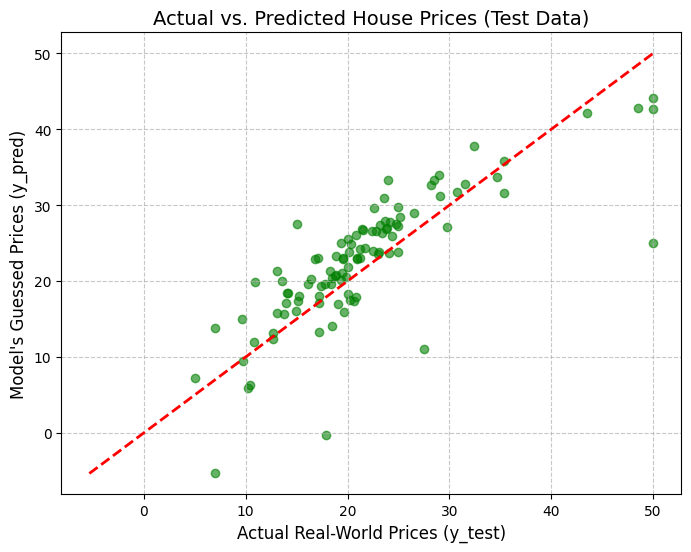

In [22]:
y_pred = compute(X_test_std, w_norm, b_norm)

print("--- First 10 Predictions vs Actual Prices ---")
for i in range(10):
    print(f"Actual: {y_test_np[i]:5.2f}  |  Predicted: {y_pred[i]:5.2f}")
print("---------------------------------------------\n")

ss_res = np.sum((y_test_np - y_pred) ** 2)
ss_tot = np.sum((y_test_np - np.mean(y_test_np)) ** 2)
r2_score = 1 - (ss_res / ss_tot)
print(f"Model Accuracy (R-squared): {r2_score * 100:.2f}%")

plt.figure(figsize=(8, 6))
plt.scatter(y_test_np, y_pred, color='green', alpha=0.6)
max_val = max(np.max(y_test_np), np.max(y_pred))
min_val = min(np.min(y_test_np), np.min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
plt.title("Actual vs. Predicted House Prices (Test Data)", fontsize=14)
plt.xlabel("Actual Real-World Prices (y_test)", fontsize=12)
plt.ylabel("Model's Guessed Prices (y_pred)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()